In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from IPython.display import display
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
import chardet


import os
for dirname, _, filenames in os.walk('./'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

./Most Streamed Spotify Songs 2024.csv
./analisis-spotify-2024.ipynb


In [2]:
df = pd.read_csv("Most Streamed Spotify Songs 2024.csv", encoding="latin-1")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Track                       4600 non-null   object 
 1   Album Name                  4600 non-null   object 
 2   Artist                      4595 non-null   object 
 3   Release Date                4600 non-null   object 
 4   ISRC                        4600 non-null   object 
 5   All Time Rank               4600 non-null   object 
 6   Track Score                 4600 non-null   float64
 7   Spotify Streams             4487 non-null   object 
 8   Spotify Playlist Count      4530 non-null   object 
 9   Spotify Playlist Reach      4528 non-null   object 
 10  Spotify Popularity          3796 non-null   float64
 11  YouTube Views               4292 non-null   object 
 12  YouTube Likes               4285 non-null   object 
 13  TikTok Posts                3427 

In [4]:
df.describe()

,Track Score,Spotify Popularity,Apple Music Playlist Count,Deezer Playlist Count,Amazon Playlist Count,TIDAL Popularity,Explicit Track
count,4600.000000,3796.000000,4039.00000,3679.000000,3545.000000,0.0,4600.000000
mean,41.844043,63.501581,54.60312,32.310954,25.348942,NaN,0.358913
std,38.543766,16.186438,71.61227,54.274538,25.989826,NaN,0.479734
min,19.400000,1.000000,1.00000,1.000000,1.000000,NaN,0.000000
25%,23.300000,61.000000,10.00000,5.000000,8.000000,NaN,0.000000
50%,29.900000,67.000000,28.00000,15.000000,17.000000,NaN,0.000000
75%,44.425000,73.000000,70.00000,37.000000,34.000000,NaN,1.000000
max,725.400000,96.000000,859.00000,632.000000,210.000000,NaN,1.000000


In [5]:
df.isnull().sum()

Track                            0
Album Name                       0
Artist                           5
Release Date                     0
ISRC                             0
All Time Rank                    0
Track Score                      0
Spotify Streams                113
Spotify Playlist Count          70
Spotify Playlist Reach          72
Spotify Popularity             804
YouTube Views                  308
YouTube Likes                  315
TikTok Posts                  1173
TikTok Likes                   980
TikTok Views                   981
YouTube Playlist Reach        1009
Apple Music Playlist Count     561
AirPlay Spins                  498
SiriusXM Spins                2123
Deezer Playlist Count          921
Deezer Playlist Reach          928
Amazon Playlist Count         1055
Pandora Streams               1106
Pandora Track Stations        1268
Soundcloud Streams            3333
Shazam Counts                  577
TIDAL Popularity              4600
Explicit Track      

In [6]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

Track                           0.000000
Album Name                      0.000000
Artist                          0.108696
Release Date                    0.000000
ISRC                            0.000000
All Time Rank                   0.000000
Track Score                     0.000000
Spotify Streams                 2.456522
Spotify Playlist Count          1.521739
Spotify Playlist Reach          1.565217
Spotify Popularity             17.478261
YouTube Views                   6.695652
YouTube Likes                   6.847826
TikTok Posts                   25.500000
TikTok Likes                   21.304348
TikTok Views                   21.326087
YouTube Playlist Reach         21.934783
Apple Music Playlist Count     12.195652
AirPlay Spins                  10.826087
SiriusXM Spins                 46.152174
Deezer Playlist Count          20.021739
Deezer Playlist Reach          20.173913
Amazon Playlist Count          22.934783
Pandora Streams                24.043478
Pandora Track St

In [7]:
df

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,For the Last Time,For the Last Time,$uicideboy$,9/5/2017,QM8DG1703420,"4,585",19.4,"305,049,963","65,770","5,103,054",...,NaN,2.0,"14,217",NaN,"20,104,066","13,184","50,633,006","656,337",NaN,1
4596,Dil Meri Na Sune,"Dil Meri Na Sune (From ""Genius"")",Atif Aslam,7/27/2018,INT101800122,"4,575",19.4,"52,282,360","4,602","1,449,767",...,NaN,1.0,927,NaN,NaN,NaN,NaN,"193,590",NaN,0
4597,Grace (feat. 42 Dugg),My Turn,Lil Baby,2/28/2020,USUG12000043,"4,571",19.4,"189,972,685","72,066","6,704,802",...,NaN,1.0,74,6.0,"84,426,740","28,999",NaN,"1,135,998",NaN,1
4598,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,11/8/2016,INY091600067,"4,591",19.4,"145,467,020","14,037","7,387,064",...,NaN,NaN,NaN,7.0,"6,817,840",NaN,NaN,"448,292",NaN,0


In [8]:
# Wherever it finds a null, it will put a zero.
df['Artist'] = df['Artist'].fillna(0)
df['Spotify Streams'] = df['Spotify Streams'].fillna(0)
df['Spotify Playlist Count'] = df['Spotify Playlist Count'].fillna(0)
df['Spotify Playlist Reach'] = df['Spotify Playlist Reach'].fillna(0)
df['Spotify Popularity'] = df['Spotify Popularity'].fillna(0)
df['YouTube Views'] = df['YouTube Views'].fillna(0)
df['YouTube Likes'] = df['YouTube Likes'].fillna(0)
df['TikTok Posts'] = df['TikTok Posts'].fillna(0)
df['TikTok Likes'] = df['TikTok Likes'].fillna(0)        
df['TikTok Views'] = df['TikTok Views'].fillna(0)        
df['YouTube Playlist Reach'] = df['YouTube Playlist Reach'].fillna(0)
df['Apple Music Playlist Count'] = df['Apple Music Playlist Count'].fillna(0)
df['AirPlay Spins'] = df['AirPlay Spins'].fillna(0)
df['SiriusXM Spins'] = df['SiriusXM Spins'].fillna(0)          
df['Deezer Playlist Count'] = df['Deezer Playlist Count'].fillna(0)
df['Deezer Playlist Reach'] = df['Deezer Playlist Reach'].fillna(0)        
df['Amazon Playlist Count'] = df['Amazon Playlist Count'].fillna(0)        
df['Pandora Streams'] = df['Pandora Streams'].fillna(0)
df['Pandora Track Stations'] = df['Pandora Track Stations'].fillna(0)
df['Soundcloud Streams'] = df['Soundcloud Streams'].fillna(0)
df['Shazam Counts'] = df['Shazam Counts'].fillna(0)
df['TIDAL Popularity'] = df['TIDAL Popularity'].fillna(0)

df.isnull().sum()

Track                         0
Album Name                    0
Artist                        0
Release Date                  0
ISRC                          0
All Time Rank                 0
Track Score                   0
Spotify Streams               0
Spotify Playlist Count        0
Spotify Playlist Reach        0
Spotify Popularity            0
YouTube Views                 0
YouTube Likes                 0
TikTok Posts                  0
TikTok Likes                  0
TikTok Views                  0
YouTube Playlist Reach        0
Apple Music Playlist Count    0
AirPlay Spins                 0
SiriusXM Spins                0
Deezer Playlist Count         0
Deezer Playlist Reach         0
Amazon Playlist Count         0
Pandora Streams               0
Pandora Track Stations        0
Soundcloud Streams            0
Shazam Counts                 0
TIDAL Popularity              0
Explicit Track                0
dtype: int64

In [9]:
df

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",0.0,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",0.0,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",0.0,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",0,"11,822,942",0.0,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,For the Last Time,For the Last Time,$uicideboy$,9/5/2017,QM8DG1703420,"4,585",19.4,"305,049,963","65,770","5,103,054",...,0,2.0,"14,217",0.0,"20,104,066","13,184","50,633,006","656,337",0.0,1
4596,Dil Meri Na Sune,"Dil Meri Na Sune (From ""Genius"")",Atif Aslam,7/27/2018,INT101800122,"4,575",19.4,"52,282,360","4,602","1,449,767",...,0,1.0,927,0.0,0,0,0,"193,590",0.0,0
4597,Grace (feat. 42 Dugg),My Turn,Lil Baby,2/28/2020,USUG12000043,"4,571",19.4,"189,972,685","72,066","6,704,802",...,0,1.0,74,6.0,"84,426,740","28,999",0,"1,135,998",0.0,1
4598,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,11/8/2016,INY091600067,"4,591",19.4,"145,467,020","14,037","7,387,064",...,0,0.0,0,7.0,"6,817,840",0,0,"448,292",0.0,0


In [10]:
#Convert to Date
df['Release Date'] = pd.to_datetime(df['Release Date'], format='%m/%d/%Y')

df["Month"] = df["Release Date"].dt.month
df["Year"] = df["Release Date"].dt.year

In [11]:
# Convert to Integer
columns_to_convert = ['All Time Rank', 'All Time Rank', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'YouTube Views', 'YouTube Likes', 'TikTok Posts','TikTok Likes',
                        'TikTok Views', 'YouTube Playlist Reach', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Reach', 'Pandora Streams', 'Pandora Track Stations', 'Shazam Counts', 'Explicit Track']

for col in columns_to_convert:
    df[col] = df[col].astype(str)  
    df[col] = df[col].str.replace(',', '')  
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int) 

In [12]:
# Convert to Decimal
columns_to_convert = ['Track Score', 'Apple Music Playlist Count', 'Deezer Playlist Count', 'Deezer Playlist Count', 'Amazon Playlist Count', 'TIDAL Popularity']

for col in columns_to_convert:
    df[col] = df[col].astype(str)  
    df[col] = df[col].str.replace(',', '')  
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)  


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Track                       4600 non-null   object        
 1   Album Name                  4600 non-null   object        
 2   Artist                      4600 non-null   object        
 3   Release Date                4600 non-null   datetime64[ns]
 4   ISRC                        4600 non-null   object        
 5   All Time Rank               4600 non-null   int64         
 6   Track Score                 4600 non-null   float64       
 7   Spotify Streams             4600 non-null   int64         
 8   Spotify Playlist Count      4600 non-null   int64         
 9   Spotify Playlist Reach      4600 non-null   int64         
 10  Spotify Popularity          4600 non-null   float64       
 11  YouTube Views               4600 non-null   int64       

In [14]:
df = df.sort_values(by='All Time Rank', ascending=True)
top_10 = df.head(10)
top_10.reset_index(drop=True, inplace=True)
display(top_10)



,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track,Month,Year
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,2024-04-26,QM24S2402528,1,725.4,390470936,30716,196631588,...,17598718,114.0,18004655,22931,"4,818,457",2669262,0.0,0,4,2024
1,Not Like Us,Not Like Us,Kendrick Lamar,2024-05-04,USUG12400910,2,545.9,323703884,28113,174597137,...,10422430,111.0,7780028,28444,"6,623,075",1118279,0.0,1,5,2024
2,i like the way you kiss me,I like the way you kiss me,Artemas,2024-03-19,QZJ842400387,3,538.4,601309283,54331,211607669,...,36321847,172.0,5022621,5639,"7,208,651",5285340,0.0,0,3,2024
3,Flowers,Flowers - Single,Miley Cyrus,2023-01-12,USSM12209777,4,444.9,2031280633,269802,136569078,...,24684248,210.0,190260277,203384,0,11822942,0.0,0,1,2023
4,Houdini,Houdini,Eminem,2024-05-31,USUG12403398,5,423.3,107034922,7223,151469874,...,17660624,105.0,4493884,7006,"207,179",457017,0.0,1,5,2024
5,Lovin On Me,Lovin On Me,Jack Harlow,2023-11-10,USAT22311371,6,410.1,670665438,105892,175421034,...,17167254,152.0,138529362,50982,"9,438,601",4517131,0.0,1,11,2023
6,Beautiful Things,Beautiful Things,Benson Boone,2024-01-18,USWB12307016,7,407.2,900158751,73118,201585714,...,48197850,154.0,65447476,57372,0,9990302,0.0,0,1,2024
7,Gata Only,Gata Only,FloyyMenor,2024-02-02,QZL382406049,8,375.8,675079153,40094,211236940,...,33245595,53.0,3372428,5762,0,6063523,0.0,1,2,2024
8,Danza Kuduro - Cover,ýýýýýýýýýýýýýýýýýýýýý - ýýýýýýýýýýýýýýýýýý -,MUSIC LAB JPN,2024-06-09,TCJPA2463708,9,355.7,1653018119,1,15,...,0,0.0,0,0,0,0,0.0,1,6,2024
9,BAND4BAND (feat. Lil Baby),BAND4BAND (feat. Lil Baby),Central Cee,2024-05-23,USSM12404354,10,330.6,90676573,10400,184199419,...,10800098,92.0,1005626,842,"3,679,709",666302,0.0,1,5,2024


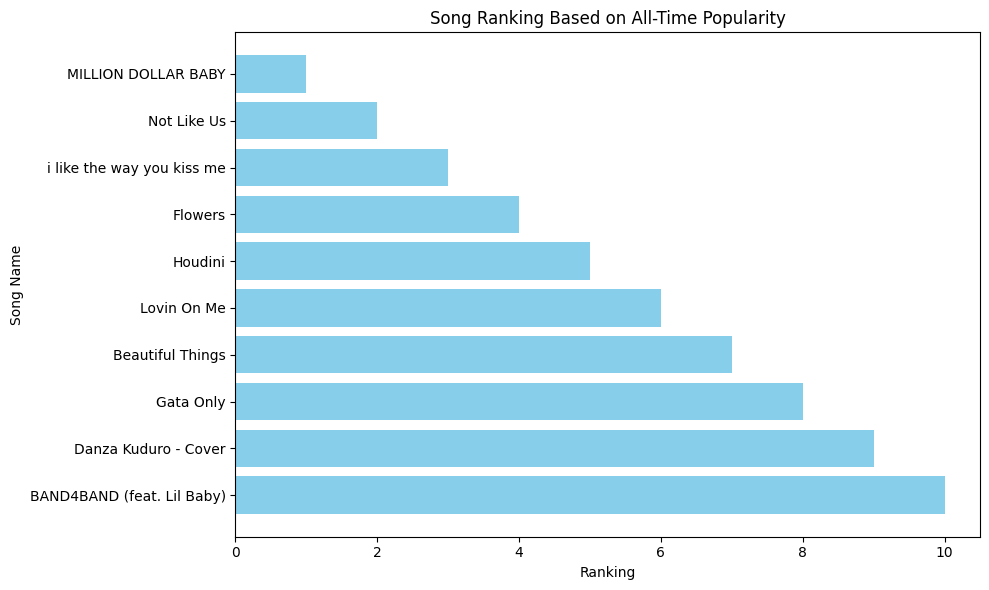

In [15]:
# Display the Top 10
plt.figure(figsize=(10, 6))
plt.barh(top_10['Track'], top_10['All Time Rank'], color='skyblue')
plt.xlabel('Ranking')
plt.ylabel('Song Name')
plt.title('Song Ranking Based on All-Time Popularity')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [16]:
df['Artist'] 
df['Artist'] = df['Artist'].str.split(',')
df['Artist']

0        [Tommy Richman]
1       [Kendrick Lamar]
2              [Artemas]
3          [Miley Cyrus]
4               [Eminem]
              ...       
4363        [Central ce]
4302      [The Platters]
4387           [corwinn]
4431        [LuckReaper]
4532        [seyhqnsert]
Name: Artist, Length: 4600, dtype: object

In [17]:
df = df.explode('Artist', ignore_index=True)
df.reset_index(drop=True, inplace=True)
        
df["Artist"] = df["Artist"].str.strip()

In [18]:
duplicated_rows = df[df.duplicated(keep=False)]
display(duplicated_rows)

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track,Month,Year
2436,Tennessee Orange,Tennessee Orange,Megan Moroney,2022-09-02,TCAGJ2289254,2424,28.9,227893586,28139,12480714,...,1370,49.0,56972562,26968,"1,336,043",708143,0.0,0,9,2022
2437,Tennessee Orange,Tennessee Orange,Megan Moroney,2022-09-02,TCAGJ2289254,2424,28.9,227893586,28139,12480714,...,1370,49.0,56972562,26968,"1,336,043",708143,0.0,0,9,2022
3459,Dembow,Dembow,Danny Ocean,2017-12-08,USWL11700269,3441,23.3,579189526,60397,11805084,...,37649,12.0,6723858,7832,0,1619550,0.0,0,12,2017
3460,Dembow,Dembow,Danny Ocean,2017-12-08,USWL11700269,3441,23.3,579189526,60397,11805084,...,37649,12.0,6723858,7832,0,1619550,0.0,0,12,2017


In [19]:
df.drop_duplicates(inplace=True)

df.reset_index(drop=True, inplace=True)

duplicated_rows = df[df.duplicated(keep=False)]
display(duplicated_rows)

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track,Month,Year


In [20]:
artist_Spotify = df.groupby('Artist')['Spotify Streams'].sum()
most_streamed_Spotify = artist_Spotify.sort_values(ascending=False).head(10)

for artist, streams in most_streamed_Spotify.items():
    print(f"{artist}: {streams} total streams")   

Bad Bunny: 37054834425 total streams
The Weeknd: 36948540278 total streams
Drake: 34962157577 total streams
Taylor Swift: 34470771165 total streams
Post Malone: 26137472958 total streams
Ed Sheeran: 24014900390 total streams
Ariana Grande: 23464991696 total streams
MUSIC LAB JPN: 22866685573 total streams
Olivia Rodrigo: 19729219749 total streams
Eminem: 18878880174 total streams


In [21]:
artist_YouTube = df.groupby('Artist')['YouTube Views'].sum()
most_streamed_YouTube = artist_YouTube.sort_values(ascending=False).head(10)

for artist, streams in most_streamed_YouTube.items():
    print(f"{artist}: {streams} total streams")   

Ed Sheeran: 27273658604 total streams
Bad Bunny: 25072757092 total streams
Taylor Swift: 20140603852 total streams
Ariana Grande: 19377678489 total streams
Justin Bieber: 19336283617 total streams
The Weeknd: 18635601580 total streams
Maroon 5: 17465688790 total streams
Katy Perry: 17400636811 total streams
KAROL G: 17173289711 total streams
BLACKPINK: 16804170656 total streams


In [22]:
artist_TikTok = df.groupby('Artist')['TikTok Views'].sum()
most_streamed_TikTok = artist_TikTok.sort_values(ascending=False).head(10)

for artist, streams in most_streamed_TikTok.items():
    print(f"{artist}: {streams} total streams")   

Kevin MacLeod: 233232311463 total streams
The King Khan & BBQ Show: 214843956590 total streams
Kreepa: 61088562861 total streams
Doja Cat: 53526243037 total streams
Tollan Kim: 48033144167 total streams
Bad Bunny: 45947009631 total streams
Cavendish Music: 38373644011 total streams
Kina: 35131541984 total streams
Meghan Trainor: 34258786673 total streams
Dante9k: 33359398879 total streams


/tmp/ipykernel_9054/1182160686.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=most_streamed_Spotify.values, y=most_streamed_Spotify.index, palette='viridis')


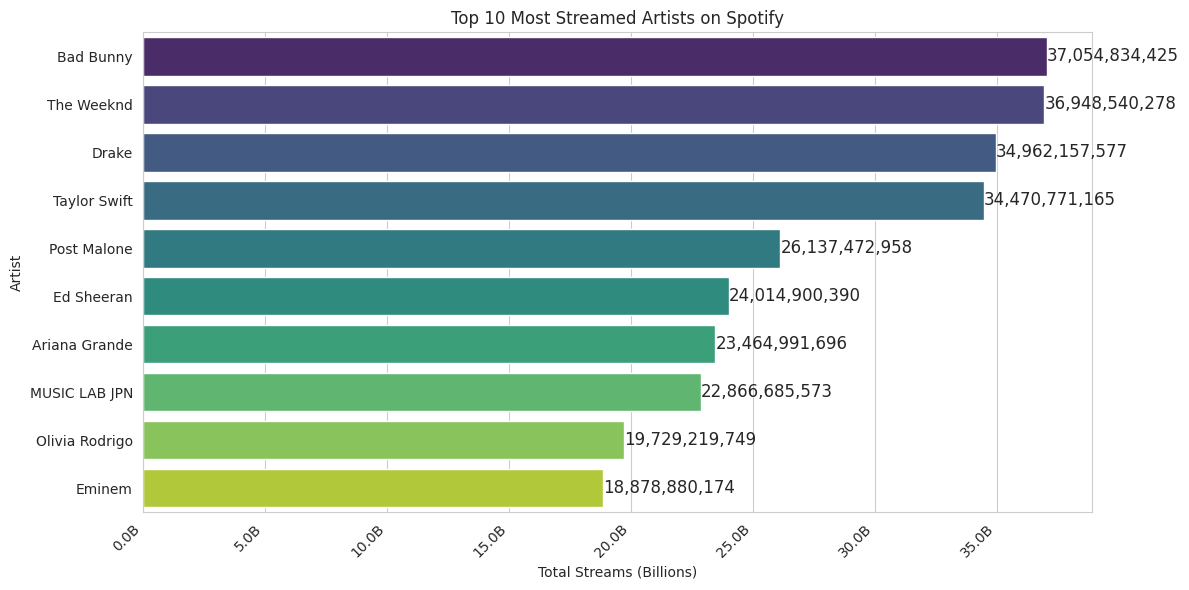

In [23]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=most_streamed_Spotify.values, y=most_streamed_Spotify.index, palette='viridis')

plt.xlabel('Total Streams (Billions)')
plt.ylabel('Artist')
plt.title('Top 10 Most Streamed Artists on Spotify')
plt.xticks(rotation=45, ha='right')
formatter = ticker.FuncFormatter(lambda x, pos: f'{x / 1e9:.1f}B')
ax.xaxis.set_major_formatter(formatter)
for i, v in enumerate(most_streamed_Spotify.values):
    ax.text(v + 10000000, i, f'{v:,}', va='center', fontsize=12)
plt.tight_layout()

plt.show()



/tmp/ipykernel_9054/3060550639.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=most_streamed_YouTube.values, y=most_streamed_YouTube.index, palette='viridis')


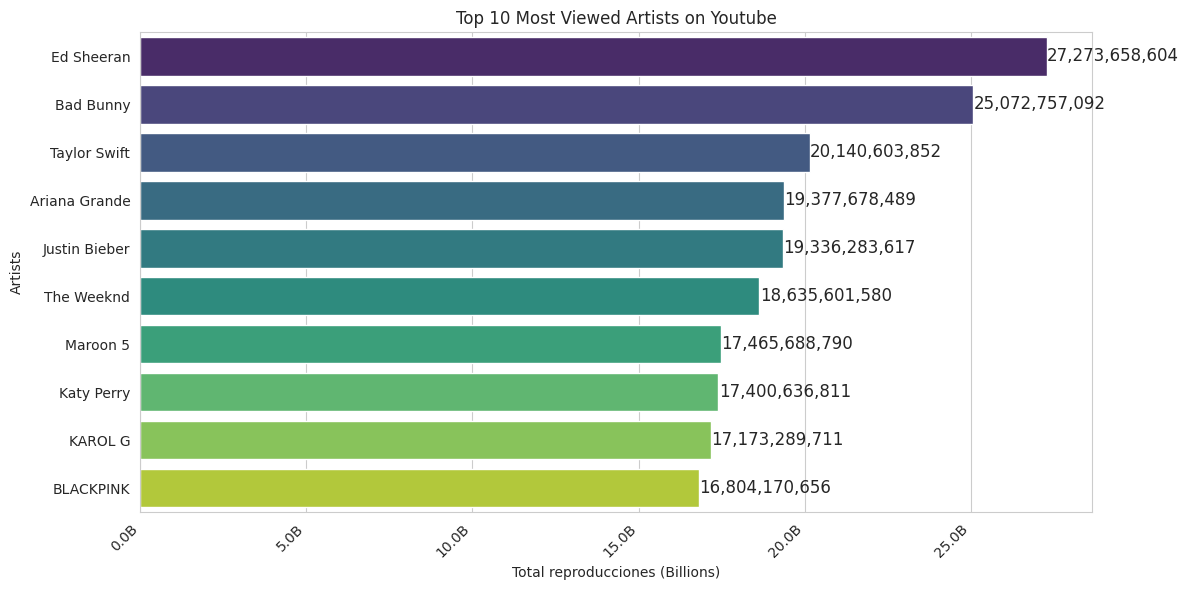

In [24]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=most_streamed_YouTube.values, y=most_streamed_YouTube.index, palette='viridis')

plt.xlabel('Total reproducciones (Billions)')
plt.ylabel('Artists')
plt.title('Top 10 Most Viewed Artists on Youtube')
plt.xticks(rotation=45, ha='right')
formatter = ticker.FuncFormatter(lambda x, pos: f'{x / 1e9:.1f}B')
ax.xaxis.set_major_formatter(formatter)
for i, v in enumerate(most_streamed_YouTube.values):
    ax.text(v + 10000000, i, f'{v:,}', va='center', fontsize=12)
plt.tight_layout()

plt.show()


In [25]:
artist_track_count = df['Artist'].value_counts()

most_tracks_artist = artist_track_count.idxmax()
num_tracks = artist_track_count.max()

print(f"The artist with the most songs is: '{most_tracks_artist}' with '{num_tracks}' songs")


The artist with the most songs is: 'Taylor Swift' with '63' songs


In [26]:
artist_track_counts = df['Artist'].value_counts()
top_10 = artist_track_counts.head(10)

print(top_10)

Artist
Taylor Swift     63
Drake            63
Bad Bunny        60
KAROL G          32
The Weeknd       31
Travis Scott     30
Billie Eilish    27
Ariana Grande    26
Future           23
Peso Pluma       22
Name: count, dtype: int64


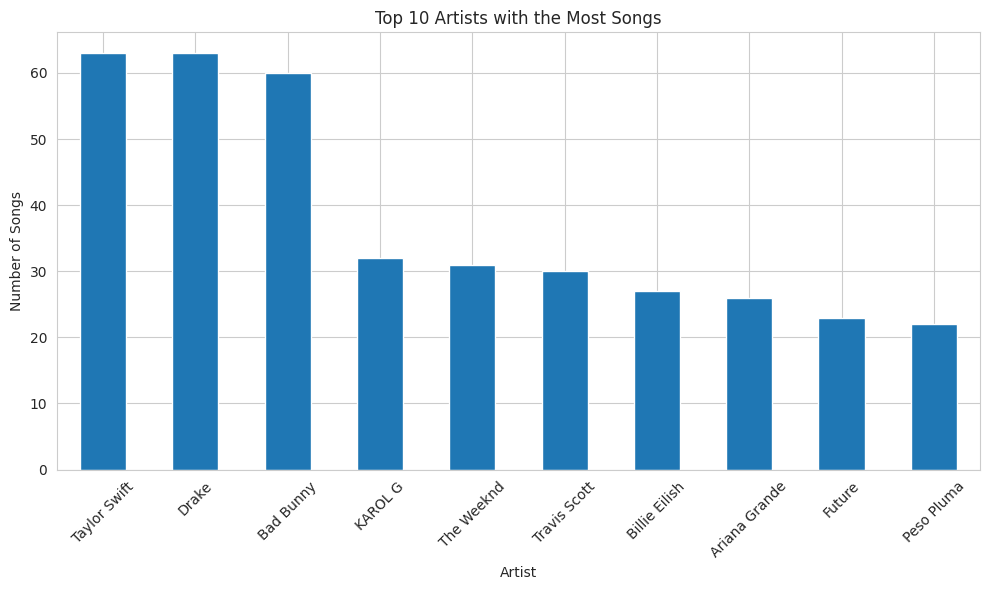

In [27]:
# Let's visualize it 
artist_track_counts = df['Artist'].value_counts()

top_10_artists = artist_track_counts.head(10)

plt.figure(figsize=(10,6))
top_10_artists.plot(kind='bar')
plt.xlabel('Artist')
plt.ylabel('Number of Songs')
plt.title('Top 10 Artists with the Most Songs')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



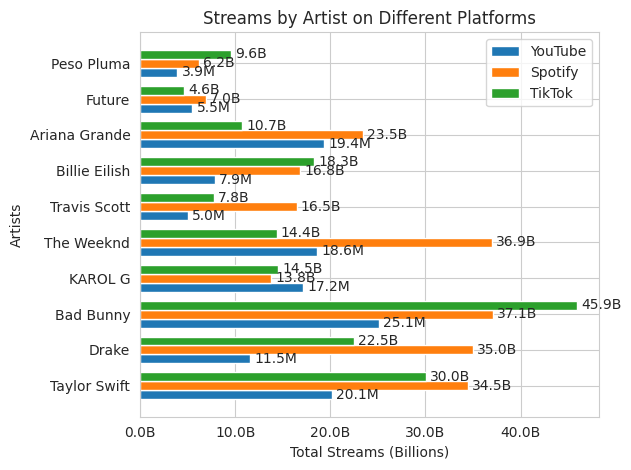

In [28]:
top_artists = df['Artist'].value_counts().index[:10]

df_top_artists = df[df['Artist'].isin(top_artists)]

youtube_views = df_top_artists.groupby('Artist')['YouTube Views'].sum().reindex(top_artists)
spotify_streams = df_top_artists.groupby('Artist')['Spotify Streams'].sum().reindex(top_artists)
tiktok_views = df_top_artists.groupby('Artist')['TikTok Views'].sum().reindex(top_artists)

y = np.arange(len(top_artists))
height = 0.25  

fig, ax = plt.subplots()

rects1 = ax.barh(y - height, youtube_views, height, label='YouTube')
rects2 = ax.barh(y, spotify_streams, height, label='Spotify')
rects3 = ax.barh(y + height, tiktok_views, height, label='TikTok')

ax.set_ylabel('Artists')
ax.set_xlabel('Total Streams (Billions)')
ax.set_title('Streams by Artist on Different Platforms')
ax.set_yticks(y)
ax.set_yticklabels(top_artists)
ax.legend()

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x / 1e9:.1f}B'))

ax.bar_label(rects1, padding=3, fmt='%.1fB', labels=[f'{x/1e9:.1f}M' for x in youtube_views])
ax.bar_label(rects2, padding=3, fmt='%.1fB', labels=[f'{x/1e9:.1f}B' for x in spotify_streams])
ax.bar_label(rects3, padding=3, fmt='%.1fB', labels=[f'{x/1e9:.1f}B' for x in tiktok_views])

plt.tight_layout()
plt.show()


In [29]:
date = df.groupby(['Month', 'Year'])['Track'].size().reset_index()
date = date[date['Year'] > 2005]

avg_month = date.groupby('Month')['Track'].mean().round()
total_month = date.groupby('Month')['Track'].sum()
year = date.groupby('Year')['Track'].sum().reset_index()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
total_month = total_month.reindex(month_order).reset_index()
avg_month = avg_month.reindex(month_order).reset_index()

In [30]:
fig = px.bar(year, x='Year', y='Track', text='Track',
            title='<b>Number of songs released each year</b><br><sub>(2006 - 2024)</sub>',
            height=700, width=1100)
fig.update_layout(title_x = 0.5)
fig.show()

# Spotify Analysis

In [31]:
artist = list(df['Artist'].head(20)[::-1])
df.columns
streams = list(df['Spotify Streams'].head(20)[::-1])
streams = ["{:,.0f}".format(x) for x in streams]

fig = px.bar(df.head(20)[::-1], x='Spotify Streams', y='Track', text=[f"{x}: {y}" for x,y in list(zip(artist,streams))], 
             color='Explicit Track',
             title='<b>Top 20 Ranked Songs on Spotify</b><br><sub>(2006 - 2024)</sub>', 
             height=900, width=1100)
fig.update_layout(title_x=0.57, yaxis={'categoryorder':'array', 'categoryarray':df['Track'].head(20)[::-1]})
fig.show()

In [32]:
spotifyStreams = df.copy()
spotifyStreams.sort_values(by='Spotify Streams', ascending=False, inplace=True)
spotifyStreams = spotifyStreams.loc[spotifyStreams['Track'].shift() != spotifyStreams['Track']]

artist = list(spotifyStreams['Artist'].head(20)[::-1])
streams = list(spotifyStreams['Spotify Streams'].head(20)[::-1])
streams = ["{:,.0f}".format(x) for x in streams]

fig = px.bar(spotifyStreams.head(20)[::-1], x='Spotify Streams', y='Track', text=[f"{x}: {y}" for x,y in list(zip(artist,streams))], 
             color='Explicit Track',
             title='<b>Top 20 Streamed Songs on Spotify</b><br><sub>(2006 - 2024)</sub>', 
             height=900, width=1100)
fig.update_layout(title_x=0.57, yaxis={'categoryorder':'array', 'categoryarray':spotifyStreams['Track'].head(20)[::-1]})
fig.update_traces(textfont_color="white")
fig.show()

# Youtube Analysis

In [33]:
youtubeViews = df.copy()
youtubeViews.sort_values(by='YouTube Views',ascending=False,inplace=True)

artist = list(youtubeViews.head(20)['Artist'][::-1])
views = list(youtubeViews.head(20)['YouTube Views'][::-1])
views = ["{:,.0f}".format(x) for x in views]

fig = px.bar(youtubeViews.head(20)[::-1], x='YouTube Views', y='Track', text=[f'{x}: {y}' for x, y in list(zip(artist,views))],
             color='Explicit Track',
             title='<b>Top 20 most viewed video on YouTube</b><br><sub>(2006 - 2024)</sub>',
             height=900, width=1100)
fig.update_layout(title_x=0.5, yaxis={'categoryorder':'array', 'categoryarray':youtubeViews['Track'].head(20)[::-1]})
fig.show()

In [34]:
youtubeLikes = df.copy()
youtubeLikes.sort_values(by='YouTube Likes',ascending=False,inplace=True)

artist = list(youtubeLikes.head(20)['Artist'][::-1])
likes = list(youtubeLikes.head(20)['YouTube Likes'][::-1])
likes = ["{:,.0f}".format(x) for x in likes]

fig = px.bar(youtubeLikes.head(20)[::-1], x='YouTube Likes', y='Track', text=[f'{x}: {y}' for x,y in list(zip(artist, likes))],
            color='Explicit Track',
            title='<b>Top 20 most liked video on YouTube</b><br><sub>(2006 - 2024)</sub>',
            height=900, width=1100)
fig.update_layout(title_x=0.5, yaxis={'categoryorder':'array', 'categoryarray':youtubeLikes['Track'].head(20)[::-1]})
fig.update_traces(textfont_color="white")
fig.show()

# TikTok Analysis

In [35]:
tiktokViews = df.copy()
tiktokViews.sort_values(by='TikTok Views',ascending=False,inplace=True)

artist = list(tiktokViews.head(20)['Artist'][::-1])
views = list(tiktokViews.head(20)['TikTok Views'][::-1])
views = ["{:,.0f}".format(x) for x in views]

fig = px.bar(tiktokViews.head(20)[::-1], x='TikTok Views', y='Track', text=[f'{x}: {y}' for x,y in list(zip(artist, likes))],
            color='Explicit Track',
            title='<b>Top 20 most used songs on TikTok</b><br><sub>(2006 - 2024)</sub>',
            height=900, width=1100)
fig.update_layout(title_x=0.5, yaxis={'categoryorder':'array', 'categoryarray':tiktokViews['Track'].head(20)[::-1]})
fig.show()

# Shazam Analysis

In [36]:
shazamCount = df.copy()
shazamCount.sort_values(by='Shazam Counts', ascending=False, inplace=True)

artist = list(shazamCount['Artist'].head(20)[::-1])
count = list(shazamCount['Shazam Counts'].head(20)[::-1])
count = ['{:,.0f}'.format(x) for x in count]

fig = px.bar(shazamCount.head(20)[::-1], x='Shazam Counts', y='Track', text=[f'{x}: {y}' for x,y in list(zip(artist, count))],
             color='Explicit Track',
             title='<b>Top 20 most searched songs on Shazam</b><br><sub>(2006 - 2024)</sub>',
             height=900, width=1100)
fig.update_layout(title_x=0.5, yaxis={'categoryorder':'array', 'categoryarray':shazamCount['Track'].head(20)[::-1]})
fig.show()

# Most Popular Artist

In [37]:
spotifyPop = df.groupby('Artist')['Spotify Streams'].sum().reset_index()
spotifyPop.sort_values(by='Spotify Streams', ascending=False, inplace=True)

streams = list(spotifyPop['Spotify Streams'].head(20)[::-1])
streams = ['{:,.0f}'.format(x) for x in streams]

fig = px.bar(spotifyPop.head(20)[::-1], x='Spotify Streams', y='Artist', text=streams,
             title='<b>Top 20 most popular artist</b><br><sub>From Spotify streams</sub>',
             height=900, width=1100)
fig.update_layout(title_x=0.5)
fig.show()

In [38]:
total_plays = df.groupby('Artist').agg(Spotify_Streams=('Spotify Streams', 'sum'), YouTube_Views=('YouTube Views', 'sum')).reset_index()
total_plays['Total Plays'] = total_plays['Spotify_Streams'] + total_plays['YouTube_Views']

spotify = df.groupby('Artist')['Spotify Streams'].sum().reset_index()
spotify.rename(columns={'Spotify Streams': 'Plays'}, inplace=True)
spotify['Media'] = 'Spotify'
spotify['Total Plays'] = total_plays['Total Plays']

youtube = df.groupby('Artist')['YouTube Views'].sum().reset_index()
youtube.rename(columns={'YouTube Views': 'Plays'}, inplace=True)
youtube['Media'] = 'YouTube'
youtube['Total Plays'] = total_plays['Total Plays']

spot_yout = pd.concat([spotify, youtube])
spot_yout.sort_values(by='Total Plays', ascending=False, inplace=True)

In [39]:
media = list(spot_yout['Media'].head(40)[::-1])
plays = list(spot_yout['Plays'].head(40)[::-1])
plays = ['{:,.0f}'.format(x) for x in plays]

fig = px.bar(spot_yout.head(40)[::-1], x='Plays', y='Artist', color='Media', text=plays,
             title='<b>Top 20 most popular artist</b><br><sub>From Spotify and YouTube plays</sub>',
             height=900, width=1100, color_discrete_sequence=['#1DB954','#d94848'])
fig.update_layout(title_x=0.5)
fig.update_traces(textfont_color="white")
fig.show()

# Choose Artist to Analyze

In [40]:
def choose_artist():
    artist = input('Choose an artist:')
    artist_df = df[df['Artist'].fillna('').str.lower().str.contains(artist.lower(), regex=False)].reset_index()
    artist_array = artist_df['Artist'].unique()

    if len(artist_array) > 1:
        return get_artist(artist_array)
    else:
        return artist_array[0]
        
def get_artist(arr):
    print('Which artist did you mean?')
    
    for x, y in enumerate(arr):
        print(f'{x}: {y}')
        
    answer = int(input('Pick artist by number:'))
    artist = arr[answer]
    return artist

In [41]:
# input function not working on kaggle but does work on jupyter
artist = choose_artist()
# artist = 'Taylor Swift'
artist_df = df[df['Artist'] == artist]
top_spo = artist_df.sort_values('Spotify Streams', ascending=False)
top_you = artist_df.sort_values('YouTube Views', ascending=False)
top_tik = artist_df.sort_values('TikTok Views', ascending=False)
top_sha = artist_df.sort_values('Shazam Counts', ascending=False)

artist_df = artist_df.sort_values('Release Date', ascending=True)
month = list(artist_df['Month'])
year = list(artist_df['Year'])

figbar = make_subplots(rows=2,cols=2, subplot_titles=('Top streamed hits<br><sub>Spotify</sub>',  'Most watched music video<br><sub>Youtube</sub>', 
                                                   'Top used songs<br><sub>TikTok</sub>', 'Top searched songs<br><sub>Shazam</sub>'))
bar1 = go.Bar(x=top_spo['Track'][:10], y=top_spo['Spotify Streams'], name='listens', marker_color='#1DB954')
bar2 = go.Bar(x=top_you['Track'][:10], y=top_you['YouTube Views'][:10], name='views', marker_color='#d94848')
bar3 = go.Bar(x=top_tik['Track'][:10], y=top_tik['TikTok Views'][:10], name='memes', marker_color='#F1C40F')
bar4 = go.Bar(x=top_sha['Track'][:10], y=top_sha['Shazam Counts'][:10], name='search', marker_color='#486fd9')
figbar.add_trace(bar1,row=1,col=1)
figbar.add_trace(bar2,row=1,col=2)
figbar.add_trace(bar3,row=2,col=1)
figbar.add_trace(bar4,row=2,col=2)
figbar.update_layout(height=1000, width=1100, title_text=f"{artist} Analysis",title_x=0.5)

figline = make_subplots(rows=1,cols=2, subplot_titles=('Spotify Score 2024',  'Total Spotify Streams'))                                                    
line1 = go.Scatter(x=artist_df['Track'], y=artist_df['Track Score'], text=[f'{x}, {y}' for x,y in list(zip(month,year))], name='Track Score', marker_color='#1DB954')
line2 = go.Scatter(x=artist_df['Track'], y=artist_df['Spotify Streams'], text=[f'{x}, {y}' for x,y in list(zip(month,year))],name='Streams', marker_color='#d94848')
figline.add_trace(line1,row=1,col=1)
figline.add_trace(line2,row=1,col=2)
figline.update_layout(height=800, width=1100, title_text=f"{artist} Song Popularity by Release Date",
                  title_x=0.48,hovermode="x unified")
figbar.show()
figline.show()